In [1]:
# Factor analysis used to find latent variables and hidden factors.
#latent variables, variables that we cannot directly observe or measure but we believe it exists.
#for example, mathematical ability is a latent variable when measure a person's math score, hoem,work score, exam score and....

# hidden factors (underlying variable factor) are those tha can be explained using smaller number of factors.
#for exampel 10 factor might be represented by factors

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis

In [5]:
# Define x and y
data = load_breast_cancer()
x = pd.DataFrame(data.data , columns=data.feature_names)
y = pd.Series(data.target)
x.head()
#These are the variables we can measure.
#The hidden factors are not in the dataset.
#Factor Analysis tries to discover them.

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
print ("number of sampels:", x.shape[0])
print(" number of features:", x.shape[1])

number of sampels: 569
 number of features: 30


In [8]:
#standardized  the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled , columns = x.columns)
x_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,2.489734,-0.565265,2.833031,2.487578,-0.214002,1.316862,0.724026,0.660820,1.148757,0.907083,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,0.499255,-0.876244,0.263327,0.742402,-0.605351,-0.692926,-0.440780,0.260162,-0.805450,-0.099444,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,1.228676,-0.780083,0.850928,1.181336,-0.297005,0.814974,0.213076,1.424827,0.237036,0.293559,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,0.326373,-0.110409,0.286593,-0.288378,0.689702,2.744280,0.819518,1.115007,4.732680,2.047511,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,1.270543,-0.790244,1.273189,1.190357,1.483067,-0.048520,0.828471,1.144205,-0.361092,0.499328,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [9]:
#Apply Factor Analysis
fa = FactorAnalysis(n_components = 5 , random_state = 42) #instead of 30 original features, we create 5 hidden factors
x_factors = fa.fit_transform(x_scaled)

In [10]:
#create a data frame of factors
factor_df = pd.DataFrame(
    x_factors,
    columns = [
        "factor 1",
        "factor 2",
        "factor 3",
        "factor 4",
        "factor 5"
    ]
)
factor_df.head()

,factor 1,factor 2,factor 3,factor 4,factor 5
0,1.287997,-1.522511,4.014474,0.013984,-2.722382
1,1.693275,-0.934095,-0.986966,1.359678,-0.842810
2,1.565225,-0.507382,0.199070,-0.319043,-0.216952
3,-0.585302,0.570610,2.740789,-2.835016,-2.287875
4,1.750753,-2.177638,-0.264136,-0.560290,0.910323


In [13]:
# factor loading; how strongly each original feature contribute to each hidden factor
loadings = pd.DataFrame(
    fa.components_.T,
    columns = [
        "factor 1",
        "factor 2",
        "factor 3",
        "factor 4",
        "factor 5"
    ],
    index = x.columns
)

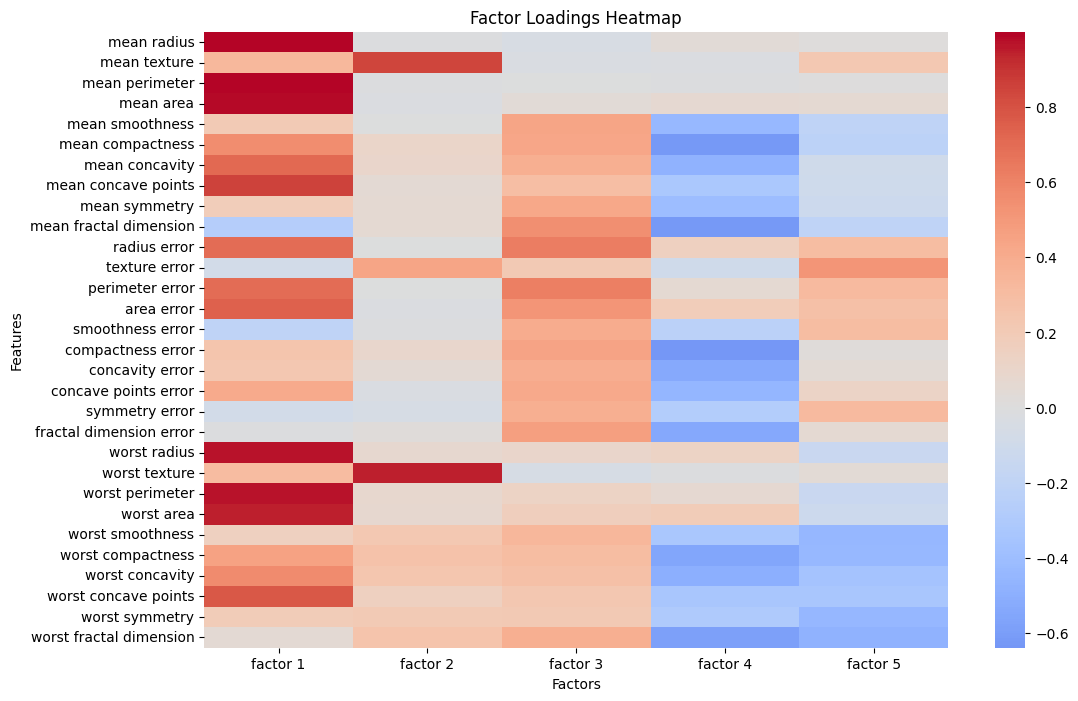

In [16]:
#visualize factor loadings
plt.figure(figsize = (12,8))

sns.heatmap(loadings, cmap = "coolwarm", center = 0)
plt.title("Factor Loadings Heatmap")

plt.xlabel("Factors")
plt.ylabel("Features")

plt.show()

In [17]:
#select strongest features for each factor
for factor in loadings.columns:
  print("\n" , factor)

  print(
      loadings[factor].abs().sort_values(ascending = False).head(5)

  )



 factor 1
mean perimeter     0.999900
mean radius        0.997960
mean area          0.987010
worst perimeter    0.972676
worst radius       0.972191
Name: factor 1, dtype: float64

 factor 2
worst texture              0.946857
mean texture               0.841904
texture error              0.442756
worst compactness          0.263711
worst fractal dimension    0.251666
Name: factor 2, dtype: float64

 factor 3
radius error               0.625081
perimeter error            0.616296
mean fractal dimension     0.546149
area error                 0.513736
fractal dimension error    0.471430
Name: factor 3, dtype: float64

 factor 4
compactness error          0.638473
mean compactness           0.629439
mean fractal dimension     0.629094
worst fractal dimension    0.585264
worst compactness          0.558247
Name: factor 4, dtype: float64

 factor 5
texture error              0.514840
worst fractal dimension    0.474048
worst smoothness           0.449937
worst symmetry             0.4435

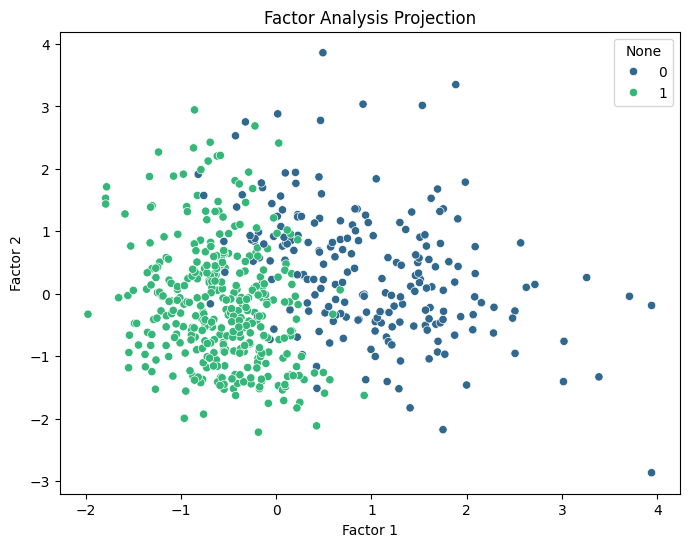

In [18]:
#visualize sampels in factor space
plt.figure(figsize=(8,6))

sns.scatterplot(
    x = factor_df["factor 1"],
    y = factor_df["factor 2"],
    hue = y,
    palette = "viridis"
)

plt.title("Factor Analysis Projection")

plt.xlabel("Factor 1")
plt.ylabel("Factor 2")

plt.show()